# Week 2: Dynamic Programming — Policy Iteration & Value Iteration
**MSDS684 Reinforcement Learning**

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import time

## 1. Custom GridWorld Environment
A 4x4 GridWorld following Gymnasium's API with configurable rewards, obstacles, and stochastic transitions.

In [36]:
class GridWorld(gym.Env):
    """4x4 GridWorld with configurable rewards, obstacles, and stochastic transitions."""

    def __init__(self, rows=4, cols=4, obstacles=None, goal=(3,3), start=(0,0),
                 step_reward=-1, goal_reward=10, obstacle_reward=-10,
                 slip_prob=0.0):
        super().__init__()
        self.rows, self.cols = rows, cols
        self.nS = rows * cols
        self.nA = 4  # 0=up, 1=right, 2=down, 3=left
        self.observation_space = gym.spaces.Discrete(self.nS)
        self.action_space = gym.spaces.Discrete(self.nA)
        self.goal = goal[0] * cols + goal[1]
        self.start = start[0] * cols + start[1]
        self.obstacles = set()
        if obstacles:
            for (r, c) in obstacles:
                self.obstacles.add(r * cols + c)
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.obstacle_reward = obstacle_reward
        self.slip_prob = slip_prob
        self.state = self.start
        # Build transition model P[s][a] = [(prob, next_state, reward, done)]
        self.P = self._build_transitions()

    def _next_state(self, s, a):
        r, c = s // self.cols, s % self.cols
        if a == 0: r = max(r - 1, 0)
        elif a == 1: c = min(c + 1, self.cols - 1)
        elif a == 2: r = min(r + 1, self.rows - 1)
        elif a == 3: c = max(c - 1, 0)
        ns = r * self.cols + c
        if ns in self.obstacles:
            return s  # blocked by obstacle
        return ns

    def _build_transitions(self):
        P = {}
        for s in range(self.nS):
            P[s] = {}
            for a in range(self.nA):
                transitions = []
                if s == self.goal or s in self.obstacles:
                    # Terminal states
                    P[s][a] = [(1.0, s, 0, True)]
                    continue
                if self.slip_prob == 0.0:
                    ns = self._next_state(s, a)
                    reward = self.goal_reward if ns == self.goal else self.step_reward
                    done = (ns == self.goal)
                    transitions.append((1.0, ns, reward, done))
                else:
                    # Stochastic: 80% intended, 10% each perpendicular
                    intended_prob = 1.0 - self.slip_prob
                    side_prob = self.slip_prob / 2.0
                    perp = {0: [1, 3], 1: [0, 2], 2: [1, 3], 3: [0, 2]}
                    for prob, act in [(intended_prob, a)] + [(side_prob, p) for p in perp[a]]:
                        ns = self._next_state(s, act)
                        reward = self.goal_reward if ns == self.goal else self.step_reward
                        done = (ns == self.goal)
                        transitions.append((prob, ns, reward, done))
                # Merge duplicate next states
                merged = {}
                for prob, ns, reward, done in transitions:
                    if ns in merged:
                        merged[ns] = (merged[ns][0] + prob, ns, reward, done)
                    else:
                        merged[ns] = (prob, ns, reward, done)
                P[s][a] = list(merged.values())
        return P

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = self.start
        return self.state, {}

    def step(self, action):
        transitions = self.P[self.state][action]
        probs = [t[0] for t in transitions]
        idx = self.np_random.choice(len(transitions), p=probs)
        _, ns, reward, done = transitions[idx]
        self.state = ns
        return ns, reward, done, False, {}

## 2. Policy Iteration (Synchronous & In-Place)

In [37]:
def policy_eval_sync(P, nS, nA, policy, gamma=0.99, theta=1e-8):
    """Synchronous policy evaluation."""
    V = np.zeros(nS)
    while True:
        V_new = np.zeros(nS)
        for s in range(nS):
            a = policy[s]
            for prob, ns, reward, done in P[s][a]:
                V_new[s] += prob * (reward + gamma * V[ns] * (1 - done))
        if np.max(np.abs(V_new - V)) < theta:
            break
        V = V_new
    return V

def policy_eval_inplace(P, nS, nA, policy, gamma=0.99, theta=1e-8):
    """In-place policy evaluation."""
    V = np.zeros(nS)
    while True:
        delta = 0
        for s in range(nS):
            v = V[s]
            a = policy[s]
            V[s] = sum(prob * (reward + gamma * V[ns] * (1 - done))
                       for prob, ns, reward, done in P[s][a])
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    return V

def policy_improvement(P, nS, nA, V, gamma=0.99):
    """Greedy policy improvement."""
    policy = np.zeros(nS, dtype=int)
    for s in range(nS):
        q = np.zeros(nA)
        for a in range(nA):
            for prob, ns, reward, done in P[s][a]:
                q[a] += prob * (reward + gamma * V[ns] * (1 - done))
        policy[s] = np.argmax(q)
    return policy

def policy_iteration(P, nS, nA, gamma=0.99, theta=1e-8, inplace=False):
    """Full policy iteration. Returns policy, V, and history of V at each iteration."""
    policy = np.zeros(nS, dtype=int)
    V_history = []
    eval_fn = policy_eval_inplace if inplace else policy_eval_sync
    while True:
        V = eval_fn(P, nS, nA, policy, gamma, theta)
        V_history.append(V.copy())
        new_policy = policy_improvement(P, nS, nA, V, gamma)
        if np.array_equal(new_policy, policy):
            break
        policy = new_policy
    return policy, V, V_history

## 3. Value Iteration (Synchronous & In-Place)

In [38]:
def value_iteration_sync(P, nS, nA, gamma=0.99, theta=1e-8):
    """Synchronous value iteration."""
    V = np.zeros(nS)
    V_history = [V.copy()]
    while True:
        V_new = np.zeros(nS)
        for s in range(nS):
            q = np.zeros(nA)
            for a in range(nA):
                for prob, ns, reward, done in P[s][a]:
                    q[a] += prob * (reward + gamma * V[ns] * (1 - done))
            V_new[s] = np.max(q)
        V_history.append(V_new.copy())
        if np.max(np.abs(V_new - V)) < theta:
            break
        V = V_new
    # Extract policy
    policy = policy_improvement(P, nS, nA, V_new, gamma)
    return policy, V_new, V_history

def value_iteration_inplace(P, nS, nA, gamma=0.99, theta=1e-8):
    """In-place value iteration."""
    V = np.zeros(nS)
    V_history = [V.copy()]
    while True:
        delta = 0
        for s in range(nS):
            v = V[s]
            q = np.zeros(nA)
            for a in range(nA):
                for prob, ns, reward, done in P[s][a]:
                    q[a] += prob * (reward + gamma * V[ns] * (1 - done))
            V[s] = np.max(q)
            delta = max(delta, abs(v - V[s]))
        V_history.append(V.copy())
        if delta < theta:
            break
    policy = policy_improvement(P, nS, nA, V, gamma)
    return policy, V, V_history

## 4. Visualization Helpers

In [39]:
ACTION_ARROWS = {0: (0, 0.3), 1: (0.3, 0), 2: (0, -0.3), 3: (-0.3, 0)}  # up,right,down,left

def plot_value_heatmap(V, rows, cols, title, obstacles=None, goal=None, ax=None):
    """Plot value function as heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    grid = V.reshape(rows, cols)
    im = ax.imshow(grid, cmap='RdYlGn', interpolation='nearest')
    for i in range(rows):
        for j in range(cols):
            s = i * cols + j
            color = 'white' if abs(grid[i, j]) > (grid.max() - grid.min()) / 2 else 'black'
            if obstacles and s in obstacles:
                ax.text(j, i, 'X', ha='center', va='center', fontsize=14, fontweight='bold', color='red')
            elif goal is not None and s == goal:
                ax.text(j, i, f'G\n{grid[i,j]:.1f}', ha='center', va='center', fontsize=9, color=color)
            else:
                ax.text(j, i, f'{grid[i,j]:.1f}', ha='center', va='center', fontsize=10, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    plt.colorbar(im, ax=ax, shrink=0.8)
    return ax

def plot_policy_arrows(policy, rows, cols, title, obstacles=None, goal=None, ax=None):
    """Plot policy as arrows on grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.grid(True, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    for i in range(rows):
        for j in range(cols):
            s = i * cols + j
            if obstacles and s in obstacles:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color='gray', alpha=0.5))
                ax.text(j, i, 'X', ha='center', va='center', fontsize=14, fontweight='bold', color='red')
            elif goal is not None and s == goal:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color='gold', alpha=0.3))
                ax.text(j, i, 'G', ha='center', va='center', fontsize=14, fontweight='bold', color='green')
            else:
                dx, dy = ACTION_ARROWS[policy[s]]
                ax.arrow(j - dx/2, i + dy/2, dx, -dy, head_width=0.15, head_length=0.1, fc='blue', ec='blue')
    return ax

## 5. Experiment 1: Deterministic GridWorld
No stochasticity — the agent moves in the intended direction 100% of the time.

In [40]:
obstacles_det = [(1, 1), (2, 2)]
env_det = GridWorld(rows=4, cols=4, obstacles=obstacles_det, goal=(3,3),
                    step_reward=-1, goal_reward=10, slip_prob=0.0)

results_det = {}
for name, fn in [("PI-Sync", lambda: policy_iteration(env_det.P, env_det.nS, env_det.nA, inplace=False)),
                 ("PI-InPlace", lambda: policy_iteration(env_det.P, env_det.nS, env_det.nA, inplace=True)),
                 ("VI-Sync", lambda: value_iteration_sync(env_det.P, env_det.nS, env_det.nA)),
                 ("VI-InPlace", lambda: value_iteration_inplace(env_det.P, env_det.nS, env_det.nA))]:
    t0 = time.time()
    policy, V, V_hist = fn()
    elapsed = time.time() - t0
    results_det[name] = {"policy": policy, "V": V, "V_hist": V_hist, "time": elapsed}
    print(f"{name}: {len(V_hist)} iterations, {elapsed:.4f}s")

PI-Sync: 7 iterations, 0.0790s
PI-InPlace: 7 iterations, 0.0834s
VI-Sync: 8 iterations, 0.0003s
VI-InPlace: 8 iterations, 0.0003s


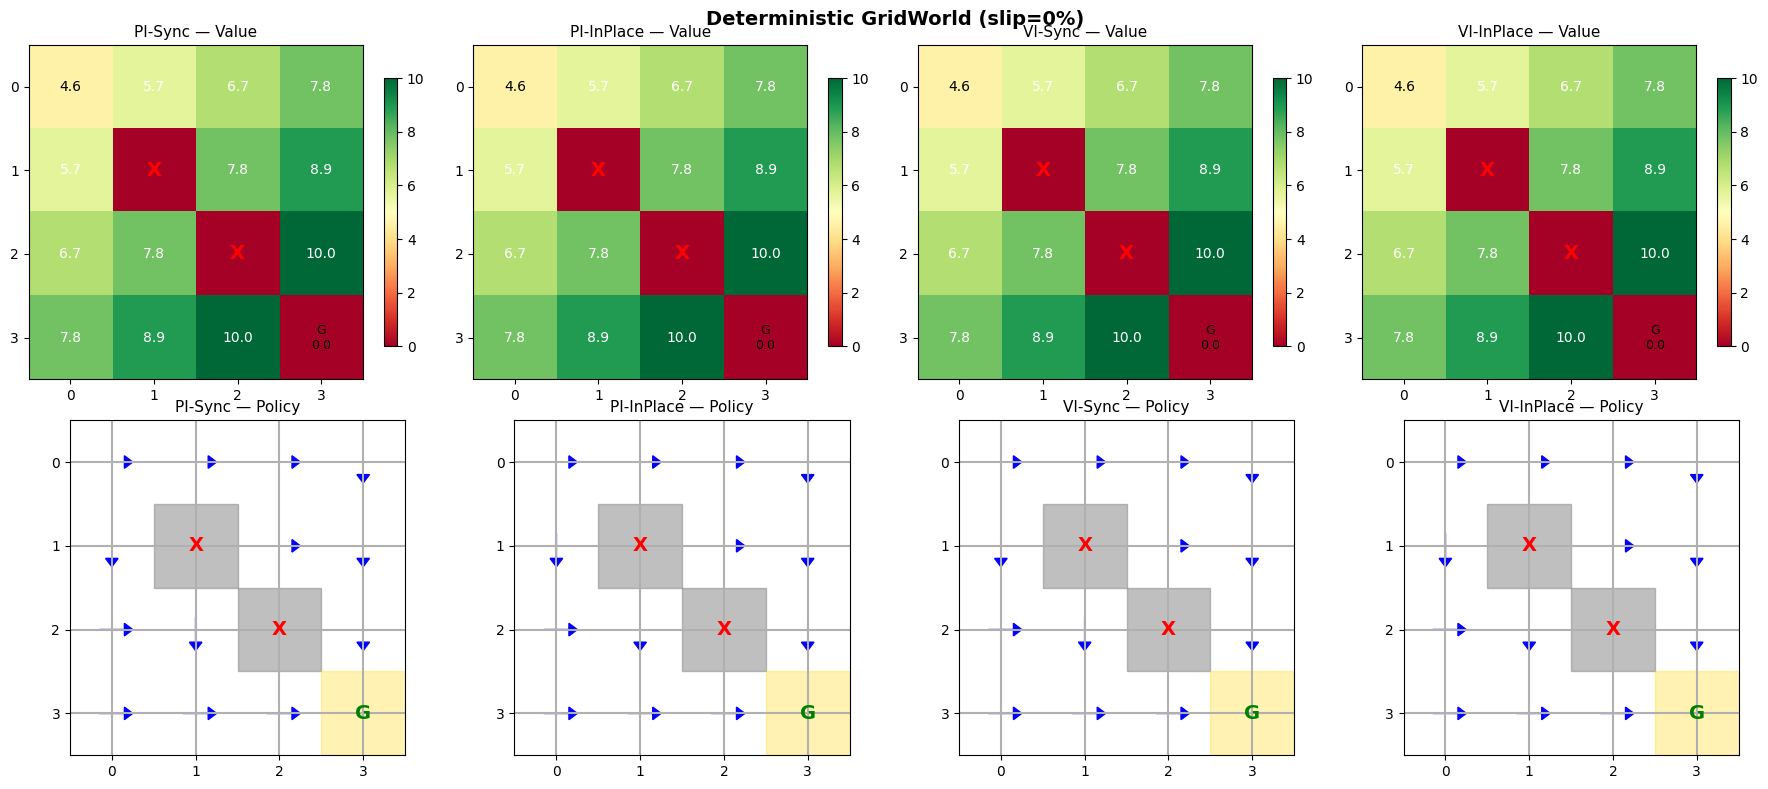

In [41]:
obs_set = {r*4+c for r,c in obstacles_det}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, name in enumerate(["PI-Sync", "PI-InPlace", "VI-Sync", "VI-InPlace"]):
    plot_value_heatmap(results_det[name]["V"], 4, 4, f"{name} — Value",
                       obstacles=obs_set, goal=env_det.goal, ax=axes[0, idx])
    plot_policy_arrows(results_det[name]["policy"], 4, 4, f"{name} — Policy",
                       obstacles=obs_set, goal=env_det.goal, ax=axes[1, idx])
fig.suptitle("Deterministic GridWorld (slip=0%)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Value Function Evolution (VI-Sync, Deterministic)

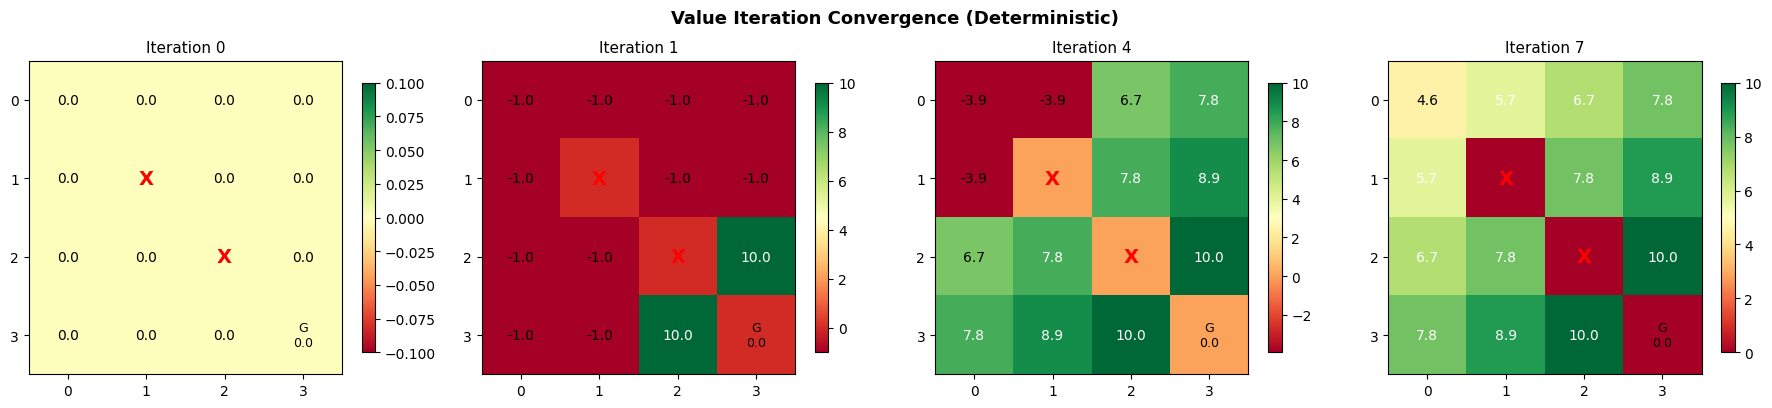

In [42]:
vi_hist = results_det["VI-Sync"]["V_hist"]
n_show = min(4, len(vi_hist))
fig, axes = plt.subplots(1, n_show, figsize=(4.5 * n_show, 4))
if n_show == 1: axes = [axes]
for i in range(n_show):
    idx = [0, 1, len(vi_hist)//2, len(vi_hist)-1][i] if len(vi_hist) > 4 else i
    plot_value_heatmap(vi_hist[idx], 4, 4, f"Iteration {idx}",
                       obstacles=obs_set, goal=env_det.goal, ax=axes[i])
fig.suptitle("Value Iteration Convergence (Deterministic)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Experiment 2: Stochastic GridWorld (slip=20%)
80% intended direction, 10% each perpendicular direction.

In [43]:
env_stoch = GridWorld(rows=4, cols=4, obstacles=obstacles_det, goal=(3,3),
                      step_reward=-1, goal_reward=10, slip_prob=0.2)

results_stoch = {}
for name, fn in [("PI-Sync", lambda: policy_iteration(env_stoch.P, env_stoch.nS, env_stoch.nA, inplace=False)),
                 ("PI-InPlace", lambda: policy_iteration(env_stoch.P, env_stoch.nS, env_stoch.nA, inplace=True)),
                 ("VI-Sync", lambda: value_iteration_sync(env_stoch.P, env_stoch.nS, env_stoch.nA)),
                 ("VI-InPlace", lambda: value_iteration_inplace(env_stoch.P, env_stoch.nS, env_stoch.nA))]:
    t0 = time.time()
    policy, V, V_hist = fn()
    elapsed = time.time() - t0
    results_stoch[name] = {"policy": policy, "V": V, "V_hist": V_hist, "time": elapsed}
    print(f"{name}: {len(V_hist)} iterations, {elapsed:.4f}s")

PI-Sync: 4 iterations, 0.0259s
PI-InPlace: 5 iterations, 0.0671s
VI-Sync: 38 iterations, 0.0022s
VI-InPlace: 28 iterations, 0.0016s


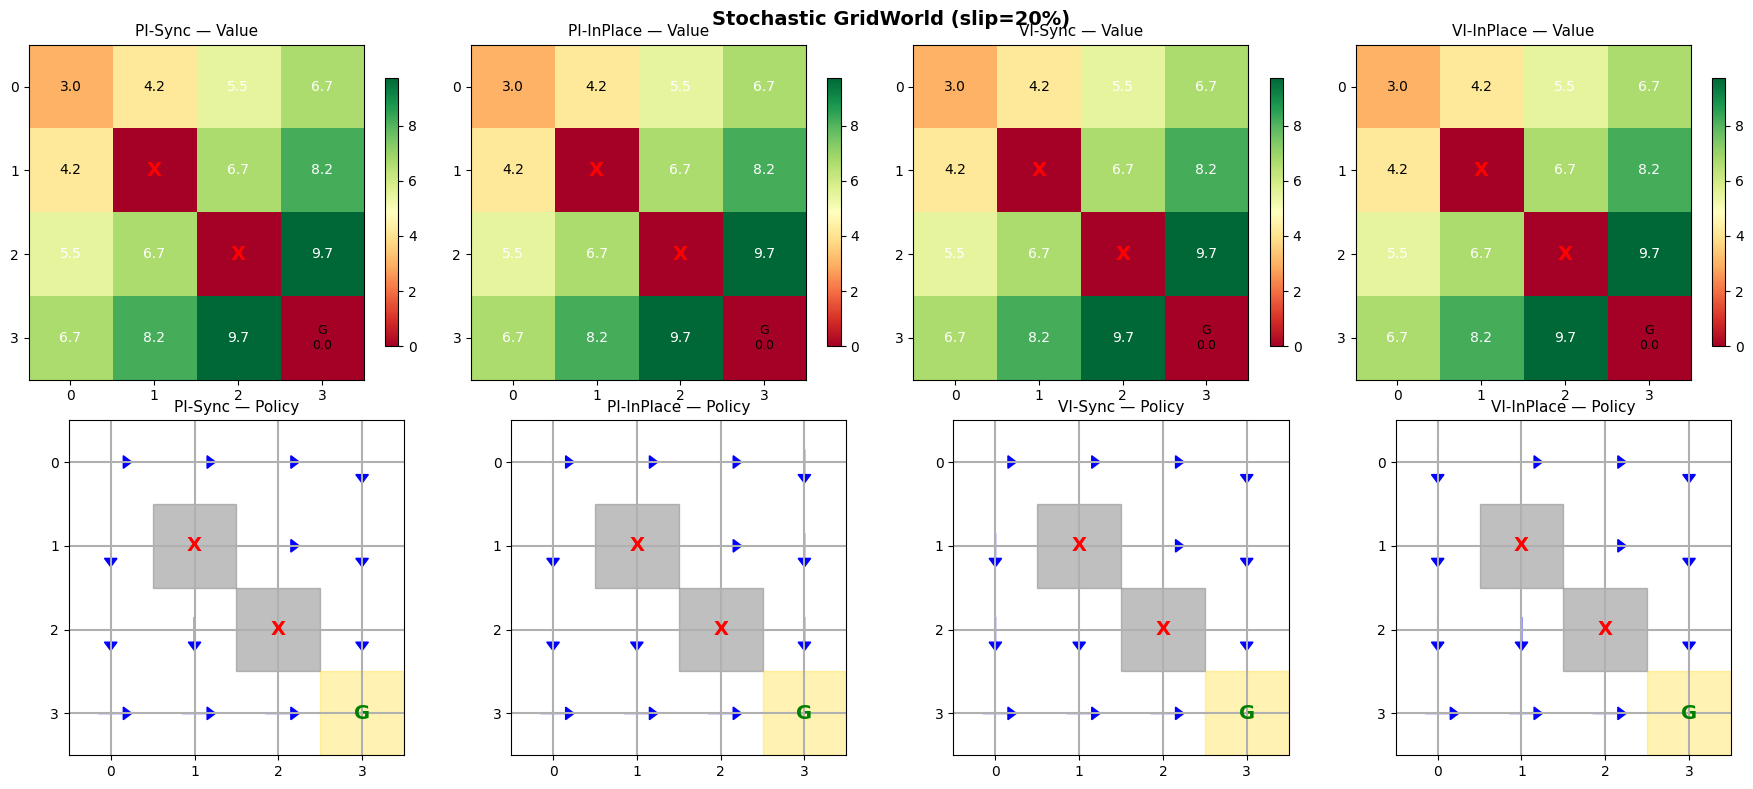

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, name in enumerate(["PI-Sync", "PI-InPlace", "VI-Sync", "VI-InPlace"]):
    plot_value_heatmap(results_stoch[name]["V"], 4, 4, f"{name} — Value",
                       obstacles=obs_set, goal=env_stoch.goal, ax=axes[0, idx])
    plot_policy_arrows(results_stoch[name]["policy"], 4, 4, f"{name} — Policy",
                       obstacles=obs_set, goal=env_stoch.goal, ax=axes[1, idx])
fig.suptitle("Stochastic GridWorld (slip=20%)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Convergence Comparison

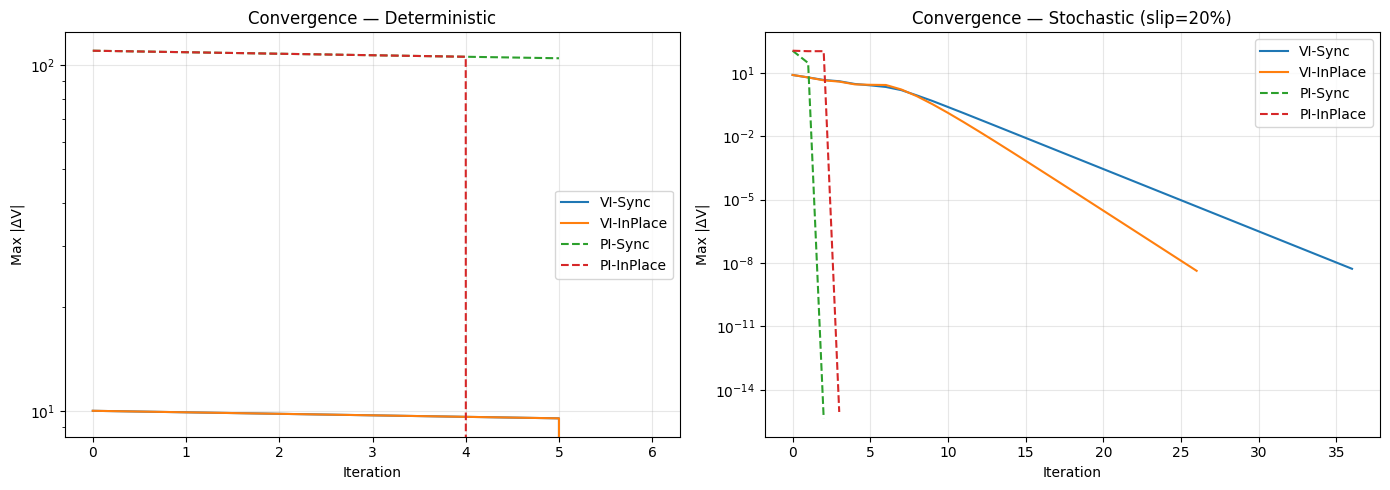

In [45]:
def max_delta_history(V_hist):
    deltas = []
    for i in range(1, len(V_hist)):
        deltas.append(np.max(np.abs(V_hist[i] - V_hist[i-1])))
    return deltas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, label in [(axes[0], results_det, "Deterministic"),
                            (axes[1], results_stoch, "Stochastic (slip=20%)")]:
    for name in ["VI-Sync", "VI-InPlace"]:
        deltas = max_delta_history(results[name]["V_hist"])
        ax.plot(deltas, label=name)
    for name in ["PI-Sync", "PI-InPlace"]:
        deltas = max_delta_history(results[name]["V_hist"])
        ax.plot(deltas, label=name, linestyle='--')
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Max |ΔV|")
    ax.set_yscale('log')
    ax.set_title(f"Convergence — {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

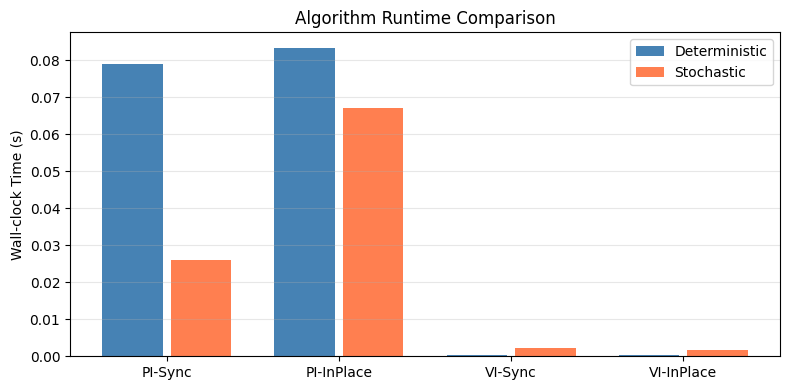

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
names = ["PI-Sync", "PI-InPlace", "VI-Sync", "VI-InPlace"]
det_times = [results_det[n]["time"] for n in names]
stoch_times = [results_stoch[n]["time"] for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, det_times, 0.35, label='Deterministic', color='steelblue')
ax.bar(x + 0.2, stoch_times, 0.35, label='Stochastic', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Wall-clock Time (s)")
ax.set_title("Algorithm Runtime Comparison")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. FrozenLake-v1
Apply DP to Gymnasium's built-in FrozenLake environment by accessing its transition dynamics directly.

In [47]:
env_fl = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
P_fl = env_fl.unwrapped.P
nS_fl = env_fl.observation_space.n
nA_fl = env_fl.action_space.n

results_fl = {}
for name, fn in [("PI-Sync", lambda: policy_iteration(P_fl, nS_fl, nA_fl, inplace=False)),
                 ("VI-Sync", lambda: value_iteration_sync(P_fl, nS_fl, nA_fl))]:
    t0 = time.time()
    policy, V, V_hist = fn()
    elapsed = time.time() - t0
    results_fl[name] = {"policy": policy, "V": V, "V_hist": V_hist, "time": elapsed}
    print(f"{name}: {len(V_hist)} iterations, {elapsed:.4f}s")

PI-Sync: 7 iterations, 0.0179s
VI-Sync: 439 iterations, 0.0254s


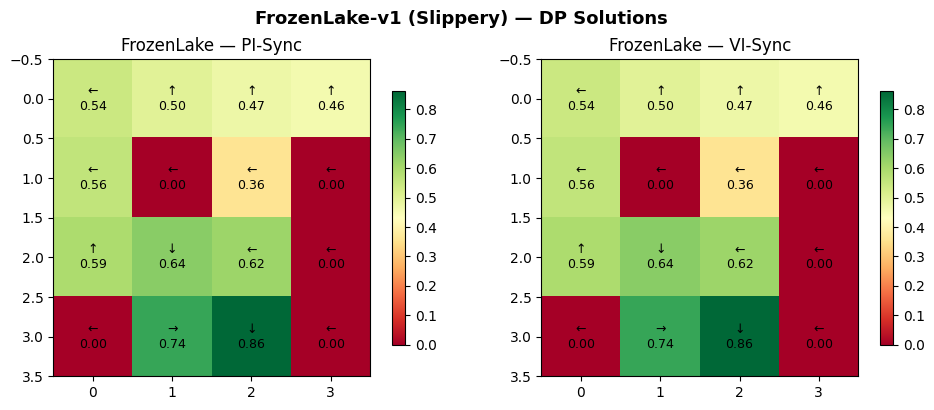

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fl_labels = {0: '←', 1: '↓', 2: '→', 3: '↑'}
for idx, name in enumerate(["PI-Sync", "VI-Sync"]):
    V_grid = results_fl[name]["V"].reshape(4, 4)
    im = axes[idx].imshow(V_grid, cmap='RdYlGn', interpolation='nearest')
    for i in range(4):
        for j in range(4):
            s = i * 4 + j
            arrow = fl_labels[results_fl[name]["policy"][s]]
            axes[idx].text(j, i, f'{arrow}\n{V_grid[i,j]:.2f}', ha='center', va='center', fontsize=9)
    axes[idx].set_title(f"FrozenLake — {name}")
    plt.colorbar(im, ax=axes[idx], shrink=0.8)
fig.suptitle("FrozenLake-v1 (Slippery) — DP Solutions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
def evaluate_policy(env, policy, n_episodes=1000):
    wins = 0
    total_reward = 0
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0
        while not done:
            action = policy[state]
            state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            done = terminated or truncated
        total_reward += ep_reward
        wins += (ep_reward > 0)
    return wins / n_episodes, total_reward / n_episodes

win_rate, avg_reward = evaluate_policy(env_fl, results_fl["VI-Sync"]["policy"])
print(f"FrozenLake VI-Sync policy: win rate = {win_rate:.1%}, avg reward = {avg_reward:.3f}")
env_fl.close()

FrozenLake VI-Sync policy: win rate = 75.7%, avg reward = 0.757


## Summary

In [50]:
for label, results in [("Deterministic", results_det), ("Stochastic", results_stoch)]:
    print(f"\n{label}:")
    for name in ["PI-Sync", "PI-InPlace", "VI-Sync", "VI-InPlace"]:
        r = results[name]
        print(f"  {name}: {len(r['V_hist'])} iters, {r['time']:.4f}s")
print(f"\nFrozenLake:")
for name in ["PI-Sync", "VI-Sync"]:
    r = results_fl[name]
    print(f"  {name}: {len(r['V_hist'])} iters, {r['time']:.4f}s")


Deterministic:
  PI-Sync: 7 iters, 0.0790s
  PI-InPlace: 7 iters, 0.0834s
  VI-Sync: 8 iters, 0.0003s
  VI-InPlace: 8 iters, 0.0003s

Stochastic:
  PI-Sync: 4 iters, 0.0259s
  PI-InPlace: 5 iters, 0.0671s
  VI-Sync: 38 iters, 0.0022s
  VI-InPlace: 28 iters, 0.0016s

FrozenLake:
  PI-Sync: 7 iters, 0.0179s
  VI-Sync: 439 iters, 0.0254s
